# Problem 2: Neuralna Mreža
Preporuka semena za sejanje na osnovu podataka o zemljištu.

In [ ]:
import numpy as np
import torch as th
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Učitavanje dataseta
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Masinsko/drugi/crop.csv')

print("Oblik dataseta:", df.shape)
print("\nNedostajuće vrednosti:", df.isnull().sum().sum())
print("\nRaspodela klasa:")
print(df['Crop'].value_counts())

Oblik dataseta: (2200, 8)

Nedostajuće vrednosti: 0

Raspodela klasa:
Crop
Rice           100
Maize          100
ChickPea       100
KidneyBeans    100
PigeonPeas     100
MothBeans      100
MungBean       100
Blackgram      100
Lentil         100
Pomegranate    100
Banana         100
Mango          100
Grapes         100
Watermelon     100
Muskmelon      100
Apple          100
Orange         100
Papaya         100
Coconut        100
Cotton         100
Jute           100
Coffee         100
Name: count, dtype: int64


In [ ]:
# Priprema podataka
X = df.drop(columns=['Crop']).values
y = df['Crop'].values

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Standardizacija feature-a (važno za neuronske mreže)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Podela na trening i test skup (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Trening skup: {X_train.shape}")
print(f"Test skup:    {X_test.shape}")
print(f"Broj klasa:   {len(le.classes_)}")

Trening skup: (1760, 7)
Test skup:    (440, 7)
Broj klasa:   22


In [ ]:
# Konverzija u PyTorch tenzore
device = 'cuda' if th.cuda.is_available() else 'cpu'
print(f"Koristimo uređaj: {device}")

X_train_t = th.tensor(X_train, dtype=th.float32, device=device)
X_test_t  = th.tensor(X_test,  dtype=th.float32, device=device)
y_train_t = th.tensor(y_train, dtype=th.long,    device=device)
y_test_t  = th.tensor(y_test,  dtype=th.long,    device=device)

Koristimo uređaj: cuda


In [ ]:
class NN:
    def __init__(self, input_size=7, hidden_size=64, output_size=22, device='cpu'):
        self.device = device

        # ISPRAVKA 1: dimenzije težina su ispravne
        # W1: (input_size x hidden_size), W2: (hidden_size x output_size)
        self.W1 = th.randn(input_size,  hidden_size, device=device) * 0.01
        self.W2 = th.randn(hidden_size, output_size, device=device) * 0.01

        # ISPRAVKA 2: dimenzije bias-a su ispravne
        # b1: (hidden_size,), b2: (output_size,)
        self.b1 = th.zeros(hidden_size, device=device)
        self.b2 = th.zeros(output_size, device=device)

        # Gradijenti
        self.dW1 = None
        self.db1 = None
        self.dW2 = None
        self.db2 = None

        # Međuvrednosti za backprop
        self.z1 = None
        self.a1 = None
        self.z2 = None
        self.a2 = None

    def relu(self, x):
        return th.maximum(th.tensor(0.0, device=self.device), x)

    def relu_izvod(self, x):
        # ISPRAVKA 3: .float() je metoda, ne atribut
        return (x > 0).float()

    def softmax(self, x):
        # Numerički stabilna varijanta
        exp_x = th.exp(x - th.max(x, dim=1, keepdim=True)[0])
        return exp_x / exp_x.sum(dim=1, keepdim=True)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1          # (N x hidden_size)
        self.a1 = self.relu(self.z1)              # (N x hidden_size)
        # ISPRAVKA 4: drugi sloj koristi W2, ne W1
        self.z2 = self.a1 @ self.W2 + self.b2    # (N x output_size)
        self.a2 = self.softmax(self.z2)           # (N x output_size)
        return self.a2

    def cross_entropy_loss(self, y_pred, y_true):
        """Unakrsna entropija: -sum(y_one_hot * log(y_pred)) / N"""
        N = y_true.size(0)
        # Izvučemo verovatnoće tačnih klasa
        log_probs = th.log(y_pred[th.arange(N), y_true] + 1e-9)
        return -log_probs.mean()

    def backward(self, X, y_true, y_pred):
        # ISPRAVKA 5: X.size(0) je poziv metode, ne pristup atributu
        N = X.size(0)

        # Gradijent gubitka po izlazu softmax-a
        dz2 = y_pred.clone()
        dz2[th.arange(N), y_true] -= 1
        dz2 /= N

        self.dW2 = self.a1.T @ dz2                         # (hidden x output)
        self.db2 = dz2.sum(dim=0)                          # (output,)

        da1 = dz2 @ self.W2.T                              # (N x hidden)
        dz1 = da1 * self.relu_izvod(self.z1)               # (N x hidden)

        self.dW1 = X.T @ dz1                               # (input x hidden)
        self.db1 = dz1.sum(dim=0)                          # (hidden,)

    def update_weights(self, learning_rate):
        self.W1 = self.W1 - learning_rate * self.dW1
        self.b1 = self.b1 - learning_rate * self.db1
        self.W2 = self.W2 - learning_rate * self.dW2
        self.b2 = self.b2 - learning_rate * self.db2

    def predict(self, X):
        probs = self.forward(X)
        return th.argmax(probs, dim=1)

In [ ]:
# Trening
input_size  = X_train.shape[1]   # 7 feature-a
hidden_size = 64
output_size = len(le.classes_)   # 22 klase

model = NN(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    device=device
)

epochs        = 500
learning_rate = 0.1
batch_size    = 64
N             = X_train_t.size(0)

losses = []

for epoch in range(epochs):
    # Mini-batch SGD
    idx = th.randperm(N, device=device)
    epoch_loss = 0.0
    num_batches = 0

    for start in range(0, N, batch_size):
        batch_idx = idx[start:start + batch_size]
        X_batch   = X_train_t[batch_idx]
        y_batch   = y_train_t[batch_idx]

        y_pred     = model.forward(X_batch)
        loss       = model.cross_entropy_loss(y_pred, y_batch)
        model.backward(X_batch, y_batch, y_pred)
        model.update_weights(learning_rate)

        epoch_loss  += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Epoha {epoch+1:4d}/{epochs} | Gubitak: {avg_loss:.4f}")

print("\nTrening završen!")

Epoha   50/500 | Gubitak: 0.1653
Epoha  100/500 | Gubitak: 0.0800
Epoha  150/500 | Gubitak: 0.0549
Epoha  200/500 | Gubitak: 0.0444
Epoha  250/500 | Gubitak: 0.0356
Epoha  300/500 | Gubitak: 0.0312
Epoha  350/500 | Gubitak: 0.0271
Epoha  400/500 | Gubitak: 0.0257
Epoha  450/500 | Gubitak: 0.0234
Epoha  500/500 | Gubitak: 0.0212

Trening završen!


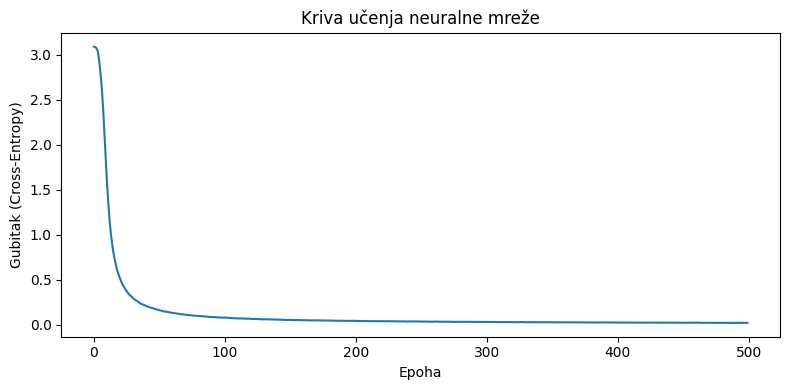

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoha')
plt.ylabel('Gubitak (Cross-Entropy)')
plt.title('Kriva učenja neuralne mreže')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Evaluacija na test skupu
y_pred_test = model.predict(X_test_t).cpu().numpy()
acc = accuracy_score(y_test, y_pred_test)

print(f"Tačnost na test skupu: {acc * 100:.2f}%")
print("\nIzveštaj klasifikacije:\n")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

Tačnost na test skupu: 99.09%

Izveštaj klasifikacije:

              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        20
      Banana       1.00      1.00      1.00        20
   Blackgram       1.00      1.00      1.00        20
    ChickPea       1.00      1.00      1.00        20
     Coconut       1.00      1.00      1.00        20
      Coffee       1.00      1.00      1.00        20
      Cotton       0.95      1.00      0.98        20
      Grapes       1.00      1.00      1.00        20
        Jute       0.90      0.95      0.93        20
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       1.00      1.00      1.00        20
       Maize       1.00      0.95      0.97        20
       Mango       1.00      1.00      1.00        20
   MothBeans       1.00      1.00      1.00        20
    MungBean       1.00      1.00      1.00        20
   Muskmelon       1.00      1.00      1.00        20
      Orange       1.00  

In [ ]:
# Primer predikcije za novi uzorak
novi_uzorak = np.array([[90, 42, 43, 20.8, 82.0, 6.5, 202.9]], dtype=np.float32)
novi_uzorak_scaled = scaler.transform(novi_uzorak)
novi_uzorak_t = th.tensor(novi_uzorak_scaled, dtype=th.float32, device=device)

predikcija = model.predict(novi_uzorak_t).cpu().numpy()
preporuka  = le.inverse_transform(predikcija)[0]
print(f"Preporučena kultura za sejanje: {preporuka}")

Preporučena kultura za sejanje: Rice
